# FFCap u_target Sweep on Exynos 5422

Sweep the `u_target` parameter on the LITTLE cluster (big stays at 1.0)
to study the trade-off between acceptance rate and deadline misses.

`u_target` is the maximum per-task utilization **on that core type** that
the allocator will accept. `scaled_utilization` converts a task's reference
utilization to the cluster-local utilization, and `u_target` thresholds it.

All configurations use EDF + GRUB scheduling with GFB admission per cluster.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("build/python").resolve()))

import json
import random
import pyschedsim as sim
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from drs import drs

In [2]:
PLATFORM = "platforms/exynos5422.json"
N_SCENARIOS = 100
SUCCESS_RATE = 1.0
COMPRESSION_RATE = 1.0
UTIL_PER_TASK_MIN = 0.01
UTIL_PER_TASK_MAX = 0.133

# Exynos 5422 capacity: 4 big (perf=1.0) + 4 LITTLE (perf=0.3334)
BIG_CAP = 4 * 1.0
LITTLE_CAP = 4 * 0.3334
PLATFORM_CAP = BIG_CAP + LITTLE_CAP  # 5.3336

UTIL_MIN = 4.1
UTIL_MAX = 6.5
UTIL_STEP = 0.2

# Need enough tasks so that N_TASKS * UTIL_PER_TASK_MAX >= UTIL_MAX
N_TASKS = int(np.ceil(UTIL_MAX / UTIL_PER_TASK_MAX))  # 49
print(f"N_TASKS = {N_TASKS}  (per-task util in [{UTIL_PER_TASK_MIN}, {UTIL_PER_TASK_MAX}])")

util_points = np.round(np.arange(UTIL_MIN, UTIL_MAX + UTIL_STEP / 2, UTIL_STEP), 4)

N_TASKS = 49  (per-task util in [0.01, 0.133])


## Compute the LITTLE cluster scale factor

`scaled_utilization(u_ref) = u_ref * scale_speed / perf`

A task with reference utilization `u_ref` is admitted on the LITTLE cluster
when `scaled_utilization(u_ref) <= u_target`, i.e.
`u_ref <= u_target / scale_factor`.

In [3]:
_engine = sim.Engine()
sim.load_platform(_engine, PLATFORM)
_platform = _engine.platform
_ref_freq_max = max(
    _platform.clock_domain(i).freq_max
    for i in range(_platform.clock_domain_count)
)

cluster_info = []
for i in range(_platform.clock_domain_count):
    cd = _platform.clock_domain(i)
    procs = cd.get_processors()
    if not procs:
        continue
    perf = procs[0].type().performance
    scale_speed = _ref_freq_max / cd.freq_max
    scale_factor = scale_speed / perf
    cluster_info.append({
        "cluster": i,
        "perf": perf,
        "freq_max": cd.freq_max,
        "scale_speed": round(scale_speed, 4),
        "scale_factor": round(scale_factor, 4),
        "n_procs": len(procs),
    })
    print(
        f"Cluster {i}: perf={perf}, freq_max={cd.freq_max}, "
        f"scale_speed={scale_speed:.4f}, scale_factor={scale_factor:.4f}"
    )

del _engine, _platform

LITTLE_SCALE = max(c["scale_factor"] for c in cluster_info if c["perf"] < 1.0)
print(f"\nLITTLE scale factor: {LITTLE_SCALE}")
print(f"u_target=0.5 → max ref util on LITTLE: {0.5 / LITTLE_SCALE:.4f}")
print(f"u_target=1.0 → max ref util on LITTLE: {1.0 / LITTLE_SCALE:.4f}")

Cluster 0: perf=1.0, freq_max=2100.0, scale_speed=1.0000, scale_factor=1.0000
Cluster 1: perf=0.3334, freq_max=1400.0, scale_speed=1.5000, scale_factor=4.4991

LITTLE scale factor: 4.4991
u_target=0.5 → max ref util on LITTLE: 0.1111
u_target=1.0 → max ref util on LITTLE: 0.2223


In [4]:
# u_target sweep values for the LITTLE cluster (big cluster stays at 1.0).
# u_target is in [0, 1]: the max per-task utilization on the LITTLE core type.
U_TARGETS = [0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
U_TARGET_LABELS = {
    ut: f"{ut:.2f} (u_ref≤{ut / LITTLE_SCALE:.3f})" for ut in U_TARGETS
}
print("u_target sweep values (max per-task util on LITTLE core):")
for ut, label in U_TARGET_LABELS.items():
    print(f"  {label}")

u_target sweep values (max per-task util on LITTLE core):
  0.10 (u_ref≤0.022)
  0.20 (u_ref≤0.044)
  0.30 (u_ref≤0.067)
  0.50 (u_ref≤0.111)
  0.75 (u_ref≤0.167)
  1.00 (u_ref≤0.222)


## Taskset generation

Generate all tasksets upfront using DRS + `from_utilizations`, then write
each scenario (with jobs) to disk in the same folder layout as `min_tasksets/`:

```
tasksets/<util_x10>/<idx>.json
```

Each JSON can be reloaded with `sim.load_scenario(path)`.

In [5]:
import os

TASKSET_DIR = "tasksets"


def generate_utilizations(n_tasks: int, total_util: float, seed: int) -> list[float]:
    """Generate per-task utilizations summing to total_util using DRS, each in [UTIL_PER_TASK_MIN, UTIL_PER_TASK_MAX]."""
    random.seed(seed)
    return drs(
        n_tasks, total_util,
        upper_bounds=[UTIL_PER_TASK_MAX] * n_tasks,
        lower_bounds=[UTIL_PER_TASK_MIN] * n_tasks,
    )


tasksets = []
for j, util in enumerate(util_points):
    folder = os.path.join(TASKSET_DIR, str(int(round(util * 10))))
    os.makedirs(folder, exist_ok=True)
    for scenario_idx in range(N_SCENARIOS):
        seed = int(round(util * 10000)) * 10000 + scenario_idx
        utils = generate_utilizations(N_TASKS, util, seed)
        scenario = sim.from_utilizations(utils, SUCCESS_RATE, COMPRESSION_RATE, seed)
        path = os.path.join(folder, f"{scenario_idx + 1}.json")
        sim.write_scenario(scenario, path)
        tasksets.append({
            "total_util": round(float(util), 4),
            "seed": seed,
            "utilizations": [float(u) for u in utils],
            "path": path,
        })
    print(f"  U={util:.1f} → {folder}/  ({j + 1}/{len(util_points)})")

print(f"\nGenerated {len(tasksets)} tasksets in {TASKSET_DIR}/")

/nix/store/r7by5rwp5pnyc4wyfl7hrxpv0438p9bi-python3-3.12.12-env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/nix/store/r7by5rwp5pnyc4wyfl7hrxpv0438p9bi-python3-3.12.12-env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/nix/store/r7by5rwp5pnyc4wyfl7hrxpv0438p9bi-python3-3.12.12-env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


  U=4.1 → tasksets/41/  (1/13)
  U=4.3 → tasksets/43/  (2/13)


  U=4.5 → tasksets/45/  (3/13)
  U=4.7 → tasksets/47/  (4/13)
  U=4.9 → tasksets/49/  (5/13)
  U=5.1 → tasksets/51/  (6/13)


  U=5.3 → tasksets/53/  (7/13)
  U=5.5 → tasksets/55/  (8/13)
  U=5.7 → tasksets/57/  (9/13)
  U=5.9 → tasksets/59/  (10/13)
  U=6.1 → tasksets/61/  (11/13)


  U=6.3 → tasksets/63/  (12/13)
  U=6.5 → tasksets/65/  (13/13)

Generated 1300 tasksets in tasksets/


## Utilization distribution

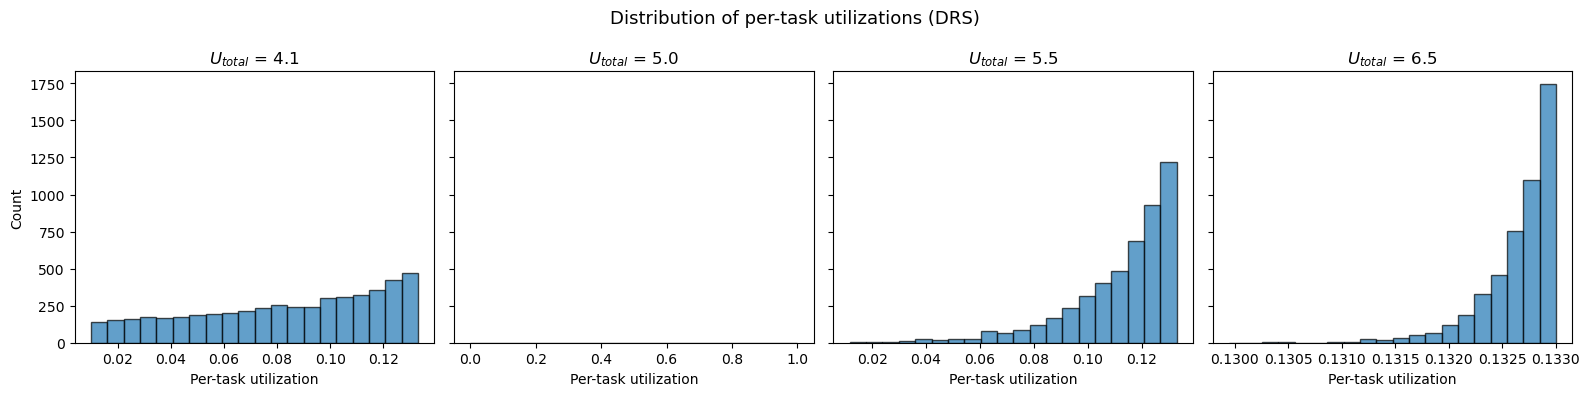

In [6]:
sample_points = [4.1, 5.0, 5.5, round(UTIL_MAX, 1)]
fig, axes = plt.subplots(1, len(sample_points), figsize=(16, 4), sharey=True)

for ax, target in zip(axes, sample_points):
    target_r = round(target, 4)
    all_utils = [u for t in tasksets if t["total_util"] == target_r for u in t["utilizations"]]
    ax.hist(all_utils, bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(f"$U_{{total}}$ = {target:.1f}")
    ax.set_xlabel("Per-task utilization")

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of per-task utilizations (DRS)", fontsize=13)
plt.tight_layout()
plt.show()

## Simulation

For each u_target value, run every taskset through FFCap on the Exynos 5422
platform with EDF + GRUB and GFB admission.

In [7]:
def run_one(taskset: dict, little_u_target: float) -> dict:
    """Run a single FFCap simulation with the given u_target on the LITTLE cluster."""
    engine = sim.Engine()
    sim.load_platform(engine, PLATFORM)
    scenario = sim.load_scenario(taskset["path"])

    tasks = sim.inject_scenario(engine, scenario)
    for i, task in enumerate(tasks):
        sim.schedule_arrivals(engine, task, scenario.tasks[i].jobs)
    engine.platform.finalize()

    platform = engine.platform
    ref_freq_max = max(
        platform.clock_domain(i).freq_max
        for i in range(platform.clock_domain_count)
    )

    clusters = []
    for i in range(platform.clock_domain_count):
        cd = platform.clock_domain(i)
        procs = cd.get_processors()
        if not procs:
            continue
        sched = sim.EdfScheduler(engine, procs)
        sched.enable_grub()
        sched.set_admission_test(sim.AdmissionTest.GFB)
        perf = procs[0].type().performance
        cluster = sim.Cluster(cd, sched, perf, ref_freq_max)
        if perf < 1.0:
            cluster.set_u_target(little_u_target)
        clusters.append(cluster)

    _alloc = sim.FFCapAllocator(engine, clusters)

    writer = sim.MemoryTraceWriter()
    engine.set_trace_writer(writer)
    engine.run()

    metrics = writer.compute_metrics()
    total_arrivals = metrics.total_jobs + metrics.rejected_arrivals

    return {
        "total_util": taskset["total_util"],
        "seed": taskset["seed"],
        "u_target": round(little_u_target, 4),
        "total_jobs": metrics.total_jobs,
        "completed_jobs": metrics.completed_jobs,
        "deadline_misses": metrics.deadline_misses,
        "rejected_arrivals": metrics.rejected_arrivals,
        "total_arrivals": total_arrivals,
    }

## Simulation — fine-grained u_target sweep

Sweep u_target from 0.20 to 1.30 in steps of 0.02 (56 values).

In [8]:
U_TARGET_FINE = np.round(np.arange(0.20, 1.30 + 0.01, 0.02), 4)
print(f"Fine sweep: {len(U_TARGET_FINE)} u_target values from {U_TARGET_FINE[0]} to {U_TARGET_FINE[-1]}")
print(f"Total simulations: {len(U_TARGET_FINE)} × {len(tasksets)} = {len(U_TARGET_FINE) * len(tasksets)}")

Fine sweep: 56 u_target values from 0.2 to 1.3
Total simulations: 56 × 1300 = 72800


In [9]:
rows = []
for ut_idx, u_target in enumerate(U_TARGET_FINE):
    for j, util in enumerate(util_points):
        batch = [t for t in tasksets if t["total_util"] == round(float(util), 4)]
        for t in batch:
            rows.append(run_one(t, float(u_target)))
        print(
            f"  u_target={u_target:.2f} | U={util:.1f} done  "
            f"({j + 1}/{len(util_points)})"
        )
    print(f"--- u_target={u_target:.2f} complete ({ut_idx + 1}/{len(U_TARGET_FINE)}) ---")

df = pl.DataFrame(rows)

  u_target=0.20 | U=4.1 done  (1/13)


  u_target=0.20 | U=4.3 done  (2/13)


  u_target=0.20 | U=4.5 done  (3/13)


  u_target=0.20 | U=4.7 done  (4/13)


  u_target=0.20 | U=4.9 done  (5/13)


...

  u_target=1.30 | U=5.7 done  (9/13)


  u_target=1.30 | U=5.9 done  (10/13)


  u_target=1.30 | U=6.1 done  (11/13)


  u_target=1.30 | U=6.3 done  (12/13)


  u_target=1.30 | U=6.5 done  (13/13)
--- u_target=1.30 complete (56/56) ---


## Results

In [10]:
summary = (
    df.group_by(["u_target", "total_util"])
    .agg(
        deadline_miss_ratio=(pl.col("deadline_misses") > 0).mean(),
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
    )
    .sort(["u_target", "total_util"])
)

### Acceptance rate vs u_target per utilization point

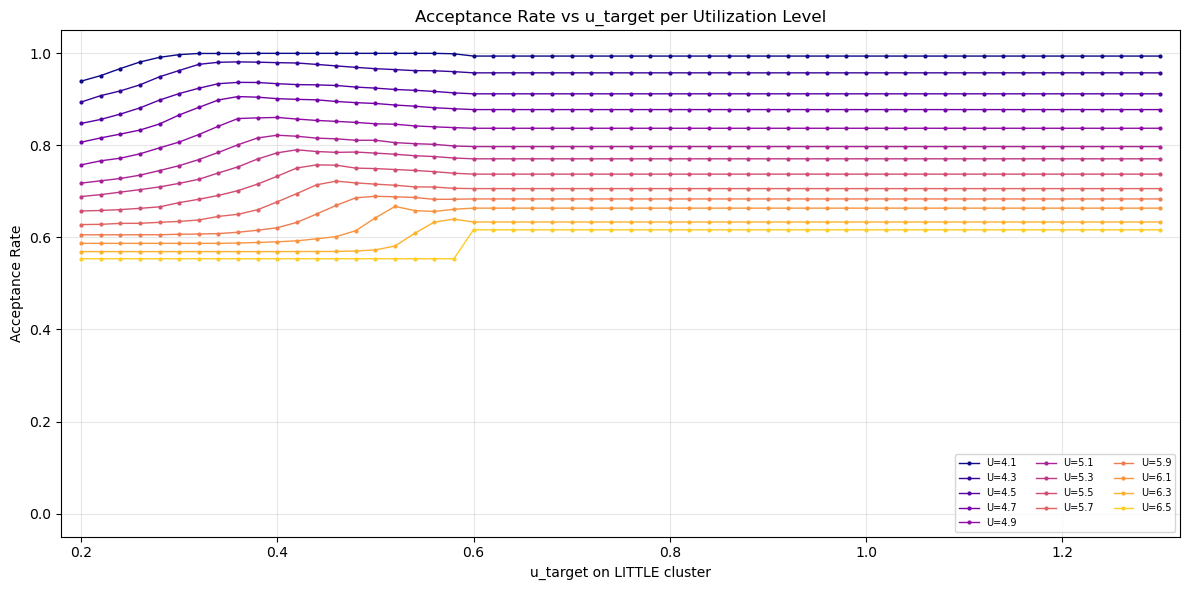

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_util = cm.plasma(np.linspace(0, 0.9, len(util_points)))
for idx, util in enumerate(util_points):
    data = summary.filter(pl.col("total_util") == round(float(util), 4)).sort("u_target")
    ax.plot(
        data["u_target"], data["acceptance_rate"],
        marker=".", color=colors_util[idx],
        label=f"U={util:.1f}", markersize=4, linewidth=1,
    )

ax.set_xlabel("u_target on LITTLE cluster")
ax.set_ylabel("Acceptance Rate")
ax.set_title("Acceptance Rate vs u_target per Utilization Level")
ax.legend(fontsize=7, ncol=3, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(U_TARGET_FINE[0] - 0.02, U_TARGET_FINE[-1] + 0.02)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### Optimal u_target per utilization point

In [12]:
best = (
    summary.sort(["total_util", "acceptance_rate"], descending=[False, True])
    .group_by("total_util", maintain_order=True)
    .first()
    .sort("total_util")
)
best

total_util,u_target,deadline_miss_ratio,acceptance_rate
f64,f64,f64,f64
4.1,0.38,0.0,1.0
4.3,0.36,0.0,0.981444
4.5,0.36,0.0,0.936917
4.7,0.36,0.0,0.906066
4.9,0.4,0.0,0.860723
…,…,…,…
5.7,0.46,0.0,0.722307
5.9,0.5,0.0,0.68943
6.1,0.52,0.0,0.667469


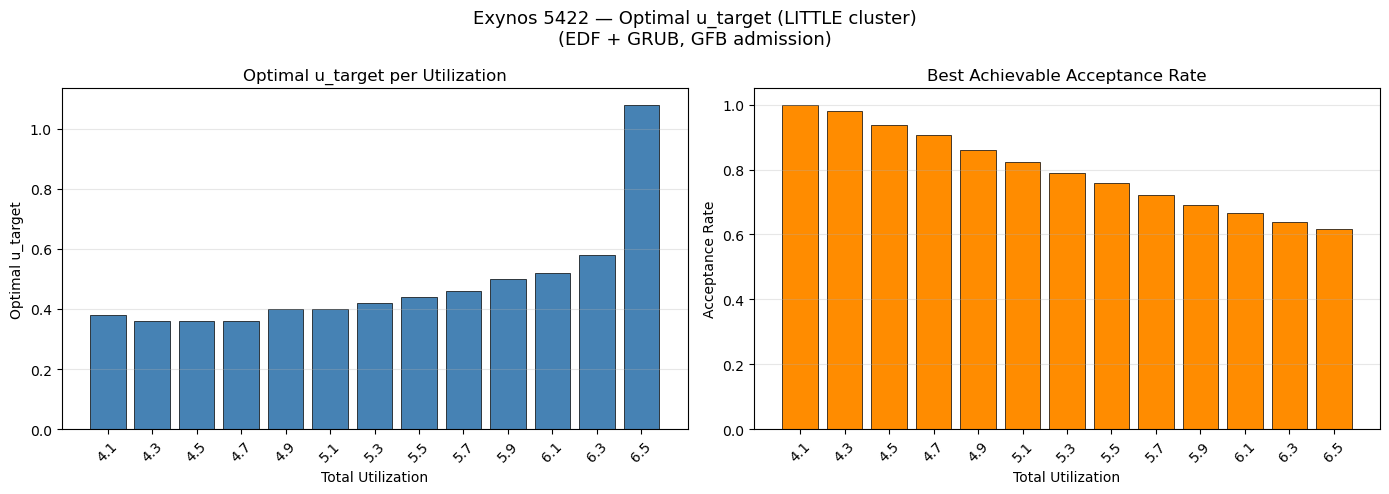

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    [f"{u:.1f}" for u in best["total_util"]],
    best["u_target"],
    color="steelblue", edgecolor="black", linewidth=0.5,
)
axes[0].set_xlabel("Total Utilization")
axes[0].set_ylabel("Optimal u_target")
axes[0].set_title("Optimal u_target per Utilization")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(
    [f"{u:.1f}" for u in best["total_util"]],
    best["acceptance_rate"],
    color="darkorange", edgecolor="black", linewidth=0.5,
)
axes[1].set_xlabel("Total Utilization")
axes[1].set_ylabel("Acceptance Rate")
axes[1].set_title("Best Achievable Acceptance Rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].set_ylim(0, 1.05)

fig.suptitle(
    "Exynos 5422 — Optimal u_target (LITTLE cluster)\n"
    "(EDF + GRUB, GFB admission)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Summary: optimal u_target across all utilization points

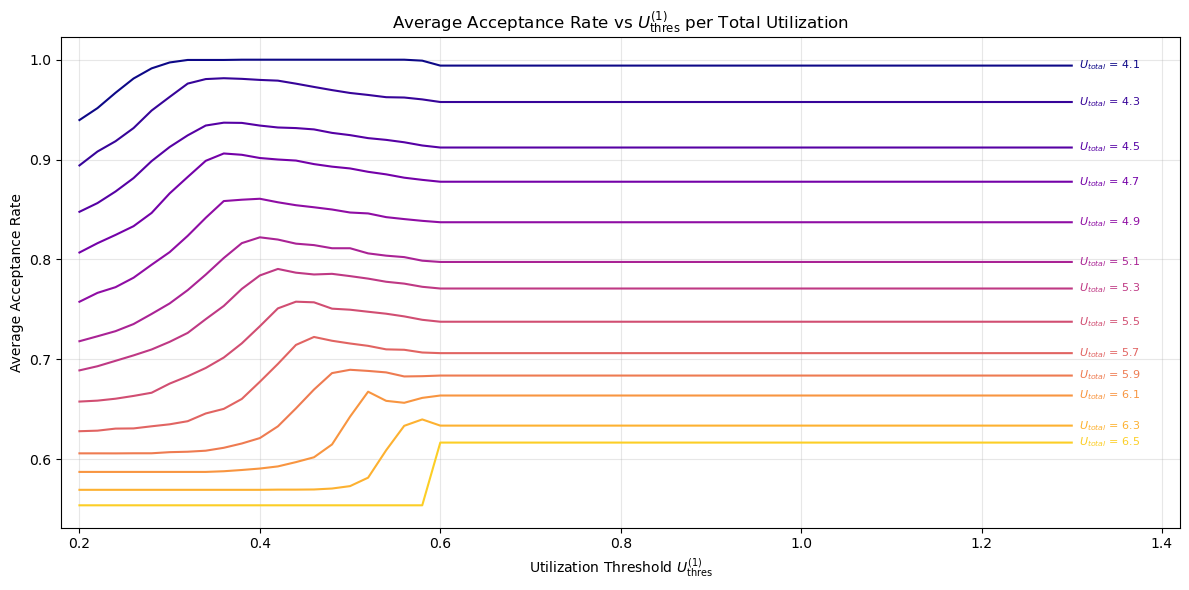

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_util = cm.plasma(np.linspace(0, 0.9, len(util_points)))
for idx, util in enumerate(util_points):
    data = summary.filter(pl.col("total_util") == round(float(util), 4)).sort("u_target")
    mean_acc = (
        data.group_by("u_target", maintain_order=True)
        .agg(mean_acceptance=pl.col("acceptance_rate").mean())
    )
    color = colors_util[idx]
    ax.plot(
        mean_acc["u_target"], mean_acc["mean_acceptance"],
        color=color, linewidth=1.5,
    )
    # Label on the right side of each curve
    last_y = mean_acc["mean_acceptance"][-1]
    ax.annotate(
        f"$U_{{total}}$ = {util:.1f}",
        xy=(float(U_TARGET_FINE[-1]), float(last_y)),
        xytext=(5, 0), textcoords="offset points",
        fontsize=8, color=color, va="center",
    )

ax.set_xlabel(r"Utilization Threshold $U_{\mathrm{thres}}^{(1)}$")
ax.set_ylabel("Average Acceptance Rate")
ax.set_title("Average Acceptance Rate vs $U_{\\mathrm{thres}}^{(1)}$ per Total Utilization")
ax.grid(True, alpha=0.3)
ax.set_xlim(U_TARGET_FINE[0] - 0.02, U_TARGET_FINE[-1] + 0.12)
plt.tight_layout()
plt.show()